# E-Commerce Sales Data Analysis

This project analyzes an e-commerce transactions dataset to understand customer behavior, sales performance, and purchasing trends.

Objectives:
- Clean and prepare the dataset
- Perform exploratory data analysis (EDA)
- Generate business insights

## Import Required Libraries

We use pandas for data manipulation and matplotlib/seaborn for visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Load Dataset

The dataset contains 50,000 e-commerce transactions including customer details, product categories, payment methods, and purchase amounts.

In [2]:
dataset = pd.read_csv("dataset/ecommerce_transactions.csv")
dataset.head()

,Transaction_ID,User_Name,Age,Country,Product_Category,Purchase_Amount,Payment_Method,Transaction_Date
0,1,Ava Hall,63,Mexico,Clothing,780.69,Debit Card,2023-04-14
1,2,Sophia Hall,59,India,Beauty,738.56,PayPal,2023-07-30
2,3,Elijah Thompson,26,France,Books,178.34,Credit Card,2023-09-17
3,4,Elijah White,43,Mexico,Sports,401.09,UPI,2023-06-21
4,5,Ava Harris,48,Germany,Beauty,594.83,Net Banking,2024-10-29


## Dataset Overview

Before cleaning the data, we inspect its structure, dimensions, and column names.

In [3]:
print(f"Rows:{dataset.shape[0]}, Columns: {dataset.shape[1]}")
dataset.columns

Rows:50000, Columns: 8


Index(['Transaction_ID', 'User_Name', 'Age', 'Country', 'Product_Category',
       'Purchase_Amount', 'Payment_Method', 'Transaction_Date'],
      dtype='object')

## Summary Statistics

This step provides statistical information about numerical columns such as purchase amount and customer age.

In [4]:
dataset.describe()

,Transaction_ID,Age,Purchase_Amount
count,50000.000000,50000.000000,50000.000000
mean,25000.500000,43.968680,503.159793
std,14433.901067,15.260578,286.563558
min,1.000000,18.000000,5.040000
25%,12500.750000,31.000000,255.450000
50%,25000.500000,44.000000,503.110000
75%,37500.250000,57.000000,751.162500
max,50000.000000,70.000000,999.980000


## Dataset Information

We inspect column data types and check for missing values.

In [5]:
dataset.info()
dataset.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    50000 non-null  int64  
 1   User_Name         50000 non-null  object 
 2   Age               50000 non-null  int64  
 3   Country           50000 non-null  object 
 4   Product_Category  50000 non-null  object 
 5   Purchase_Amount   50000 non-null  float64
 6   Payment_Method    50000 non-null  object 
 7   Transaction_Date  50000 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 3.1+ MB


Transaction_ID      0
User_Name           0
Age                 0
Country             0
Product_Category    0
Purchase_Amount     0
Payment_Method      0
Transaction_Date    0
dtype: int64

## Data Type Conversion

Some columns need to be converted to appropriate data types for analysis.


In [6]:
dataset['User_Name'] = dataset['User_Name'].astype(str)
dataset['Transaction_Date'] = pd.to_datetime(dataset['Transaction_Date'])

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction_ID    50000 non-null  int64         
 1   User_Name         50000 non-null  object        
 2   Age               50000 non-null  int64         
 3   Country           50000 non-null  object        
 4   Product_Category  50000 non-null  object        
 5   Purchase_Amount   50000 non-null  float64       
 6   Payment_Method    50000 non-null  object        
 7   Transaction_Date  50000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 3.1+ MB


## Data Cleaning

We check for duplicate records and remove any invalid values.

In [8]:
dataset.duplicated().sum()
dataset = dataset.drop_duplicates()

In [9]:
dataset = dataset[dataset['Purchase_Amount'] > 0]

## Feature Engineering

We create additional features from the transaction date to enable time-based analysis.

In [10]:
dataset['Year'] = dataset['Transaction_Date'].dt.year
dataset['Month'] = dataset['Transaction_Date'].dt.month
dataset['Day'] = dataset['Transaction_Date'].dt.day
dataset['Day_of_Week'] = dataset['Transaction_Date'].dt.day_name()

## Exploratory Data Analysis

This section explores key patterns in the dataset such as revenue distribution and purchasing behavior.

In [11]:
dataset.groupby('Product_Category')['Purchase_Amount'].sum().sort_values(ascending=False)

Product_Category
Sports            3195335.90
Toys              3185652.36
Books             3181897.30
Clothing          3171225.96
Electronics       3133965.04
Grocery           3123579.52
Home & Kitchen    3108945.78
Beauty            3057387.79
Name: Purchase_Amount, dtype: float64

In [12]:
dataset.groupby('Country')['Purchase_Amount'].sum().sort_values(ascending=False)

Country
France       2545739.19
Canada       2544335.12
USA          2541220.22
Mexico       2534475.67
Australia    2514911.65
Brazil       2507287.54
India        2503542.71
Germany      2502442.20
Japan        2492312.20
UK           2471723.15
Name: Purchase_Amount, dtype: float64

## Data Visualization
Visualizations help identify trends in product categories and monthly sales.

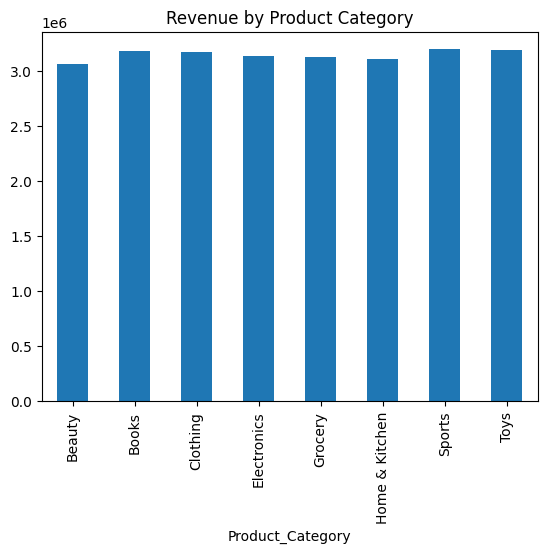

In [13]:
dataset.groupby('Product_Category')['Purchase_Amount'].sum().plot(kind='bar')
plt.title("Revenue by Product Category")
plt.show()

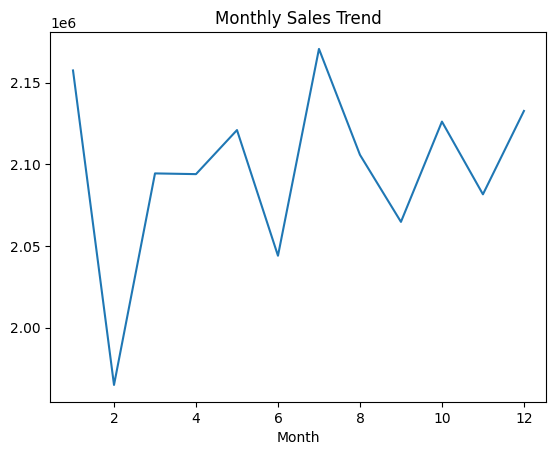

In [14]:
dataset.groupby('Month')['Purchase_Amount'].sum().plot(kind='line')
plt.title("Monthly Sales Trend")
plt.show()

## Export Cleaned Dataset

The cleaned dataset is exported for further analysis in SQL and dashboard tools like Power BI.

In [15]:
dataset.to_csv("cleaned_ecommerce_transactions.csv", index=False)

In [16]:
!pip install --upgrade sqlalchemy

## Loading Data into MySQL

The cleaned dataset is imported into a MySQL database to perform SQL-based analytics.

In [17]:
import sqlalchemy
sqlalchemy.__version__

'2.0.48'

In [19]:
from sqlalchemy import create_engine

username = "root"
password = "Your Password"
host = "localhost"
port = 3306
database = "ecommerce"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

dataset.to_sql("transactions", engine, if_exists="replace", index=False)

50000

In [20]:
pd.read_sql("SELECT * FROM transactions LIMIT 5;", engine)

,Transaction_ID,User_Name,Age,Country,Product_Category,Purchase_Amount,Payment_Method,Transaction_Date,Year,Month,Day,Day_of_Week
0,1,Ava Hall,63,Mexico,Clothing,780.69,Debit Card,2023-04-14,2023,4,14,Friday
1,2,Sophia Hall,59,India,Beauty,738.56,PayPal,2023-07-30,2023,7,30,Sunday
2,3,Elijah Thompson,26,France,Books,178.34,Credit Card,2023-09-17,2023,9,17,Sunday
3,4,Elijah White,43,Mexico,Sports,401.09,UPI,2023-06-21,2023,6,21,Wednesday
4,5,Ava Harris,48,Germany,Beauty,594.83,Net Banking,2024-10-29,2024,10,29,Tuesday


## Conclusion

The dataset was cleaned, validated, and prepared for analysis. Key transformations included:

- Converting transaction dates
- Removing duplicates
- Feature engineering for time analysis
- Exporting cleaned data for SQL and dashboard analytics

This dataset will be used for further business analysis such as:
- Revenue trends
- Customer purchasing behavior
- Product category performance